<a href="https://colab.research.google.com/github/khanuja74/khanuja74/blob/main/Google_Play_Store_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Apps dataset shape: (10841, 13)
User reviews dataset shape: (64295, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
None

Missing Values:
App                  0
Category             0
Rating   

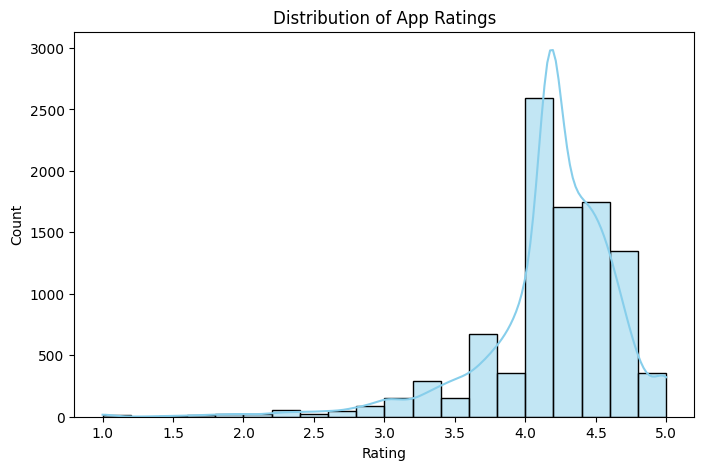

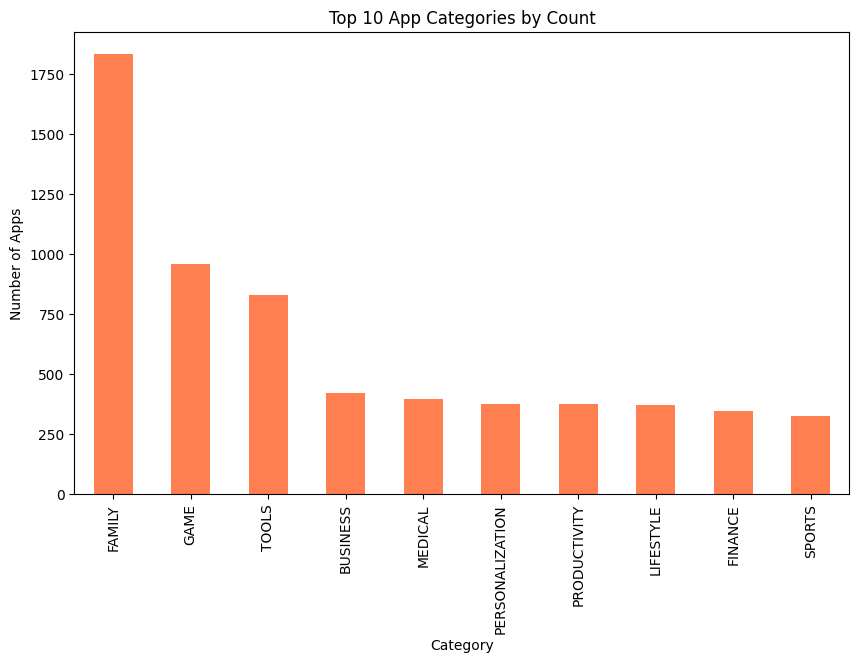

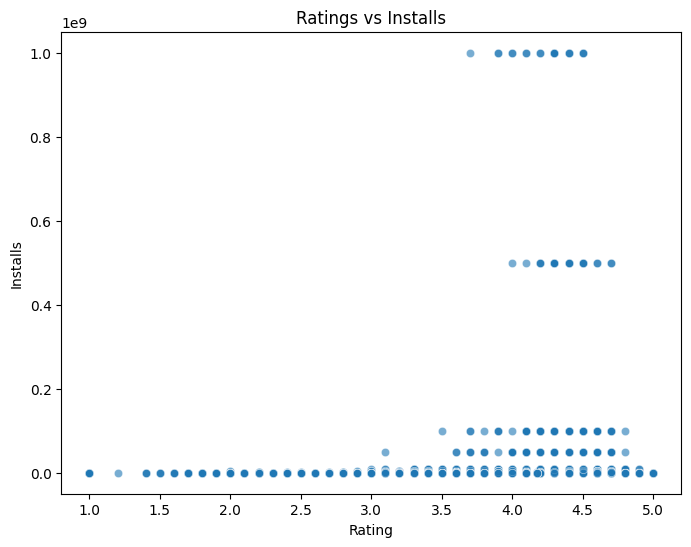

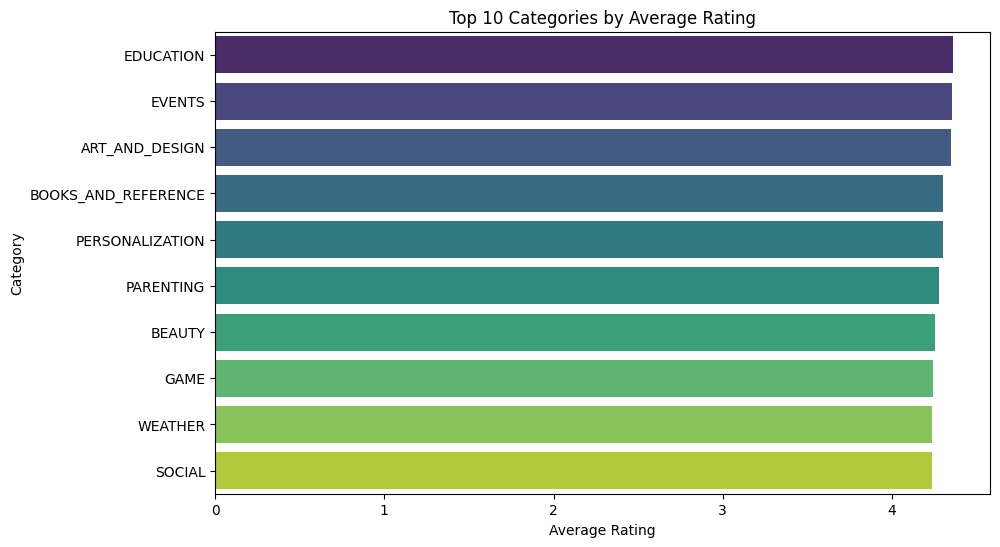


📊 Key Insights:
1. Total Apps: 9659
2. Average App Rating: 4.17
3. Top Category by Count: FAMILY
4. Most Installed App: Google Play Books

Merged dataset shape: (61556, 18)


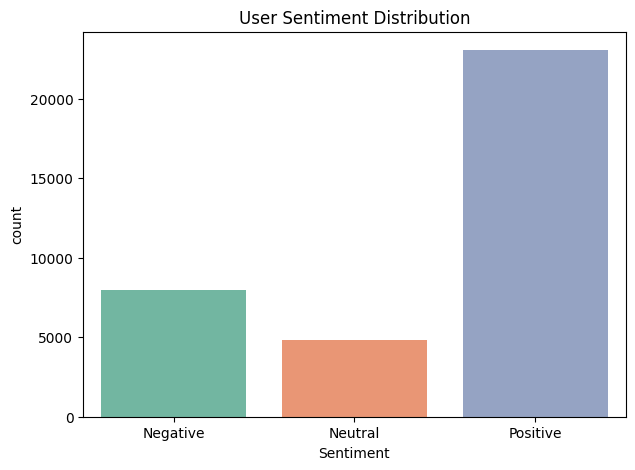

In [3]:
# Google Play Store Apps Data Analysis Project

# 1️⃣ Import Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 2️⃣ Load the Datasets
apps_df = pd.read_csv("googleplaystore.csv")
reviews_df = pd.read_csv("googleplaystore_user_reviews.csv")

print("Apps dataset shape:", apps_df.shape)
print("User reviews dataset shape:", reviews_df.shape)
apps_df.head()

# 3️⃣ Explore Basic Info
print("\nDataset Info:")
print(apps_df.info())

print("\nMissing Values:")
print(apps_df.isnull().sum())

# 4️⃣ Clean the Data
apps_df.drop_duplicates(subset='App', inplace=True)
apps_df['Rating'].fillna(apps_df['Rating'].mean(), inplace=True)

# Handle the 'Free' value in 'Installs' before converting to float
apps_df = apps_df[apps_df['Installs'] != 'Free']
apps_df['Installs'] = apps_df['Installs'].str.replace('+', '', regex=False).str.replace(',', '', regex=False).astype(float)

apps_df['Price'] = apps_df['Price'].str.replace('$', '', regex=False).astype(float)
apps_df['Reviews'] = pd.to_numeric(apps_df['Reviews'], errors='coerce').fillna(0).astype(int)

def convert_size(size):
    if 'M' in str(size):
        return float(size.replace('M', '')) * 1024
    elif 'k' in str(size):
        return float(size.replace('k', ''))
    else:
        return np.nan

apps_df['Size_KB'] = apps_df['Size'].apply(convert_size)

# 5️⃣ Summary Statistics
print("\nSummary of Numeric Columns:")
print(apps_df.describe())

# 6️⃣ Data Visualization
plt.figure(figsize=(8,5))
sns.histplot(apps_df['Rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of App Ratings')
plt.show()

plt.figure(figsize=(10,6))
apps_df['Category'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title('Top 10 App Categories by Count')
plt.ylabel('Number of Apps')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x='Rating', y='Installs', data=apps_df, alpha=0.6)
plt.title('Ratings vs Installs')
plt.show()

avg_rating = apps_df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=avg_rating.values, y=avg_rating.index, palette='viridis')
plt.title('Top 10 Categories by Average Rating')
plt.xlabel('Average Rating')
plt.show()

# 7️⃣ Key Insights
print("\n📊 Key Insights:")
print("1. Total Apps:", len(apps_df))
print("2. Average App Rating:", round(apps_df['Rating'].mean(), 2))
print("3. Top Category by Count:", apps_df['Category'].value_counts().idxmax())
print("4. Most Installed App:", apps_df.loc[apps_df['Installs'].idxmax(), 'App'])

# 8️⃣ Merge with User Reviews (Optional)
merged_df = pd.merge(apps_df, reviews_df, on='App', how='inner')
print("\nMerged dataset shape:", merged_df.shape)

plt.figure(figsize=(7,5))
sns.countplot(x='Sentiment', data=merged_df, palette='Set2')
plt.title('User Sentiment Distribution')
plt.show()